### Import / Familiarize with data

In [45]:
from IPython.core.pylabtools import figsize
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = load_wine()
X = data.data
y = data.target

print(X.shape, y.shape)
print(type(X))
print(type(y))

(178, 13) (178,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [46]:
data.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [47]:
data.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [48]:
np.bincount(y)

array([59, 71, 48])

### Numerical pipeline + StandardScaler + PCA

 - Datasets from sklearn are always complete and purely numerical, so there is no need to fill in missing data

In [49]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

X_pca = pca_pipeline.fit_transform(X)
pca_model = pca_pipeline.named_steps['pca']
print(X_pca.shape)
print(pca_model.explained_variance_ratio_)

(178, 2)
[0.36198848 0.1920749 ]


### 2D visualization

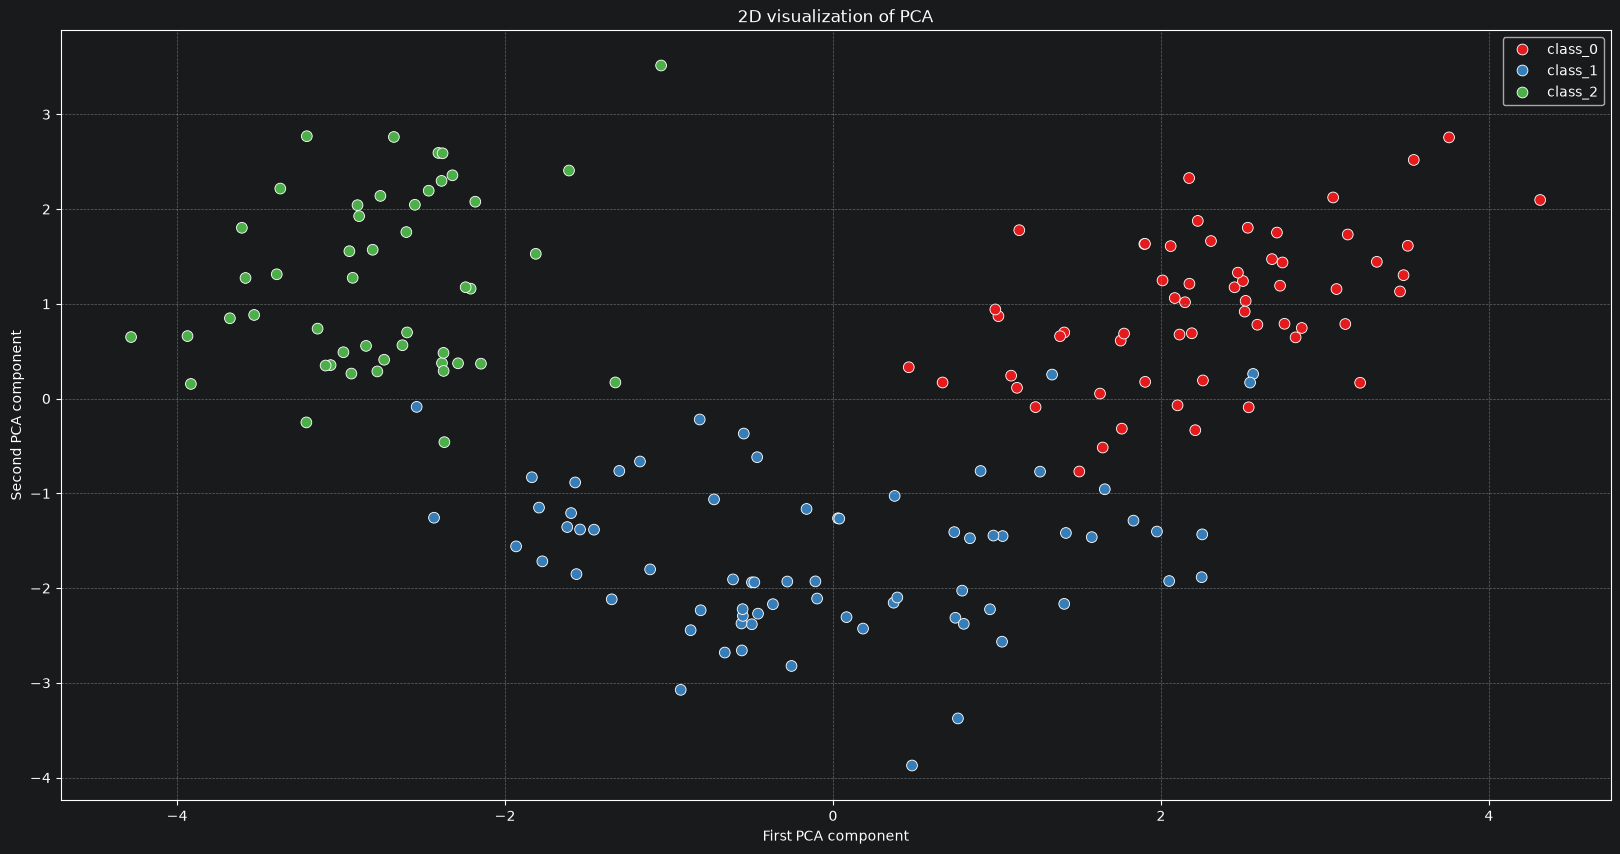

In [50]:
pca1 = X_pca[:, 0]
pca2 = X_pca[:, 1]
wine_class = data.target_names[y]

plt.figure(figsize=(20, 10))
sns.scatterplot(x=pca1, y=pca2, hue=wine_class, palette='Set1', s=60)
plt.title("2D visualization of PCA")
plt.xlabel("First PCA component")
plt.ylabel("Second PCA component")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### What PCA actually do ?

 - PCA hyperparameter e.g. `n_components=2` reduce number of features to 2
 - Thanks to PCA, we gain fewer features, which translates into faster data processing

### K-Means, silhouette score and inertia

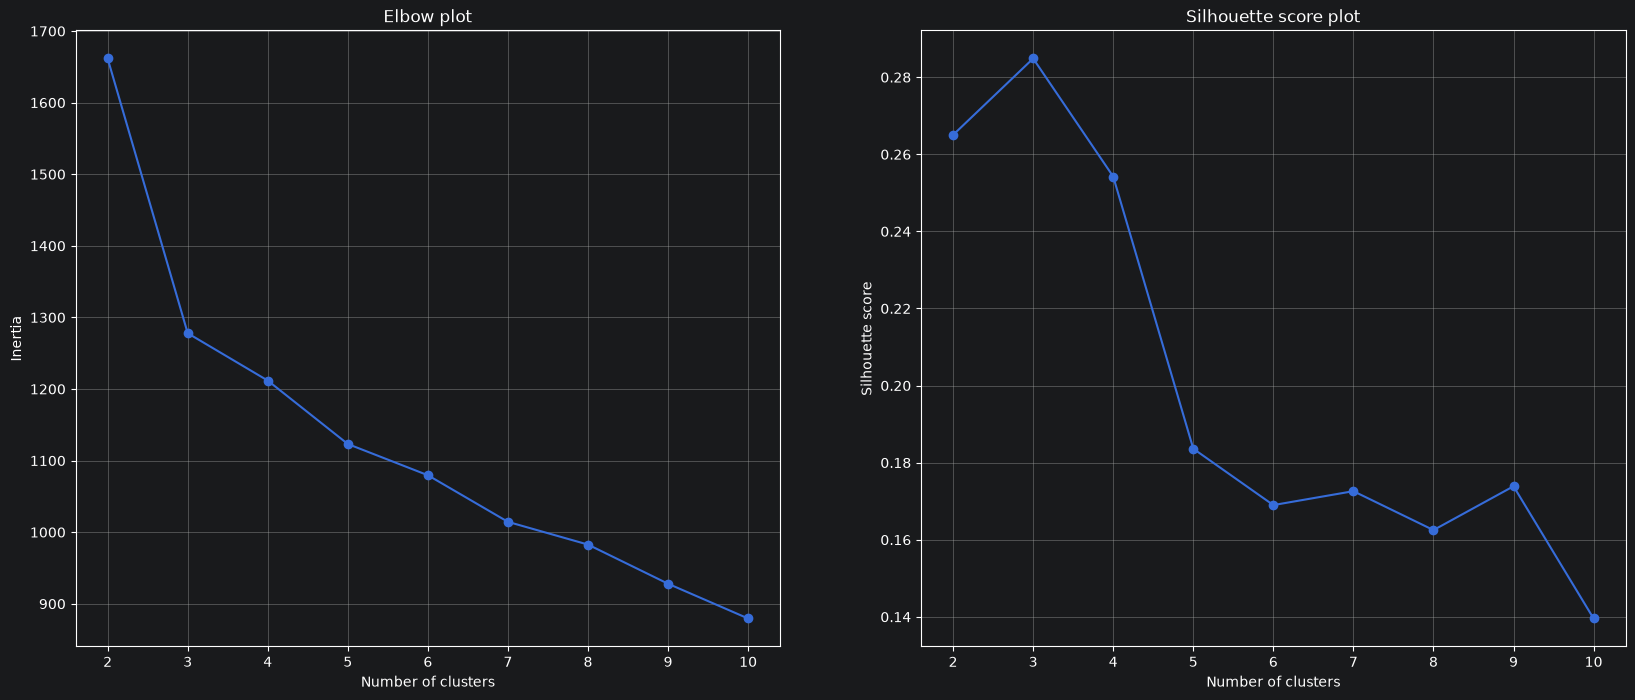

In [56]:
inertias = []
silhouettes = []

for k in range(2, 11):
    km_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=k, random_state=42))
])

    km_pipeline.fit(X)
    inertia = km_pipeline['kmeans'].inertia_
    inertias.append(inertia)

    X_scaled = km_pipeline[:-1].transform(X)
    labels = km_pipeline['kmeans'].labels_
    score = silhouette_score(X_scaled, labels)
    silhouettes.append(score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.plot(range(2, 11), inertias, marker='o', linestyle='-', label='Inertia')
ax1.set_title("Elbow plot")
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Inertia")
ax1.grid(True)

ax2.plot(range(2, 11), silhouettes, marker='o', linestyle='-', label='Inertia')
ax2.set_title("Silhouette score plot")
ax2.set_xlabel("Number of clusters")
ax2.set_ylabel("Silhouette score")
ax2.grid(True)

### Inertia and silhouette score
 - The elbow is noticeable at the level of three clusters
 - Highest value of silhouette score is 3 clusters

So, from both charts we can see that 3 clusters is the best value for this dataset